### Imports

In [1]:
# System utilities
import os
import sys
from typing import List, Dict, Tuple
from collections import defaultdict
import json
import tempfile
import fitz

import asyncio
import nest_asyncio

# Essential libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, ImageDraw, ImageFont
import pandas as pd

# PDF handling
import pdfplumber
from pypdf import PdfReader, PdfWriter
from pdf2image import convert_from_path

# OCR utilities
import pytesseract

# Graph utilities
import networkx as nx
import plotly.graph_objects as go

# ML utilities
from sklearn.cluster import DBSCAN

# Deep Learning utilities
import torch
import torch.nn as nn
import torchvision
import transformers
from transformers import LayoutLMv2Processor, LayoutLMv2ForTokenClassification
from datasets import load_dataset

import together
from together import AsyncTogether


2025-05-01 17:19:43.455114: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-01 17:19:43.749884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746100183.851927  159804 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746100183.875752  159804 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746100184.054364  159804 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
TOGETHER_API_KEY1 = input("Please enter your Together API key: ")
TOGETHER_API_KEY2 = input("Please enter your Together API key: ")

### Paths

In [6]:
pdf_file_path = os.path.join(os.getcwd(), "Assignment3.pdf")

In [7]:
def split_pdf_pages(input_pdf_path, output_pdf_prefix="page"):
    try:
        with open(input_pdf_path, 'rb') as pdf_file:
            pdf_reader = PdfReader(pdf_file)

            if len(pdf_reader.pages) >= 1:
                # Save the first page
                pdf_writer_page1 = PdfWriter()
                pdf_writer_page1.add_page(pdf_reader.pages[0])
                with open(f"{output_pdf_prefix}_1.pdf", 'wb') as output_page1:
                    pdf_writer_page1.write(output_page1)
                print(f"First page saved as '{output_pdf_prefix}_1.pdf'")

            if len(pdf_reader.pages) >= 2:
                # Save the second page
                pdf_writer_page2 = PdfWriter()
                pdf_writer_page2.add_page(pdf_reader.pages[1])
                with open(f"{output_pdf_prefix}_2.pdf", 'wb') as output_page2:
                    pdf_writer_page2.write(output_page2)
                print(f"Second page saved as '{output_pdf_prefix}_2.pdf'")

            if len(pdf_reader.pages) < 2:
                print("The PDF has less than two pages.")

    except FileNotFoundError:
        print(f"Error: The file '{input_pdf_path}' was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [8]:
split_pdf_pages(pdf_file_path)

First page saved as 'page_1.pdf'
Second page saved as 'page_2.pdf'


In [9]:
test_sample_1 = os.path.join(os.getcwd(), "page_1.pdf")
test_sample_2 = os.path.join(os.getcwd(), "page_2.pdf")

In [10]:
print(os.path.basename(test_sample_1))
print(os.path.basename(test_sample_2))

page_1.pdf
page_2.pdf


#### testing

In [11]:
def pdf_to_images(pdf_path, output_dir="output_images", output_prefix="page"):
    try:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)

        images = convert_from_path(pdf_path, first_page=1, last_page=2)

        for i, image in enumerate(images):
            output_path = os.path.join(output_dir, f"{output_prefix}_{i+1}.png")
            image.save(output_path, "PNG")
            print(f"Page {i+1} saved as '{output_path}'")

    except FileNotFoundError:
        print(f"Error: The file '{pdf_path}' was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [12]:
pdf_to_images(pdf_file_path)

Page 1 saved as 'output_images/page_1.png'
Page 2 saved as 'output_images/page_2.png'


In [13]:
def display_images_subplot(image_dir="output_images", prefix="page"):
    image_paths = [
        os.path.join(image_dir, f"{prefix}_1.png"),
        os.path.join(image_dir, f"{prefix}_2.png"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    for i, ax in enumerate(axes):
        try:
            img = mpimg.imread(image_paths[i])
            ax.imshow(img)
            ax.set_title(f"Page {i+1}")
            ax.axis('off')
        except FileNotFoundError:
            ax.text(0.5, 0.5, f"Image '{os.path.basename(image_paths[i])}' not found",
                    horizontalalignment='center', verticalalignment='center',
                    fontsize=12, color='red')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

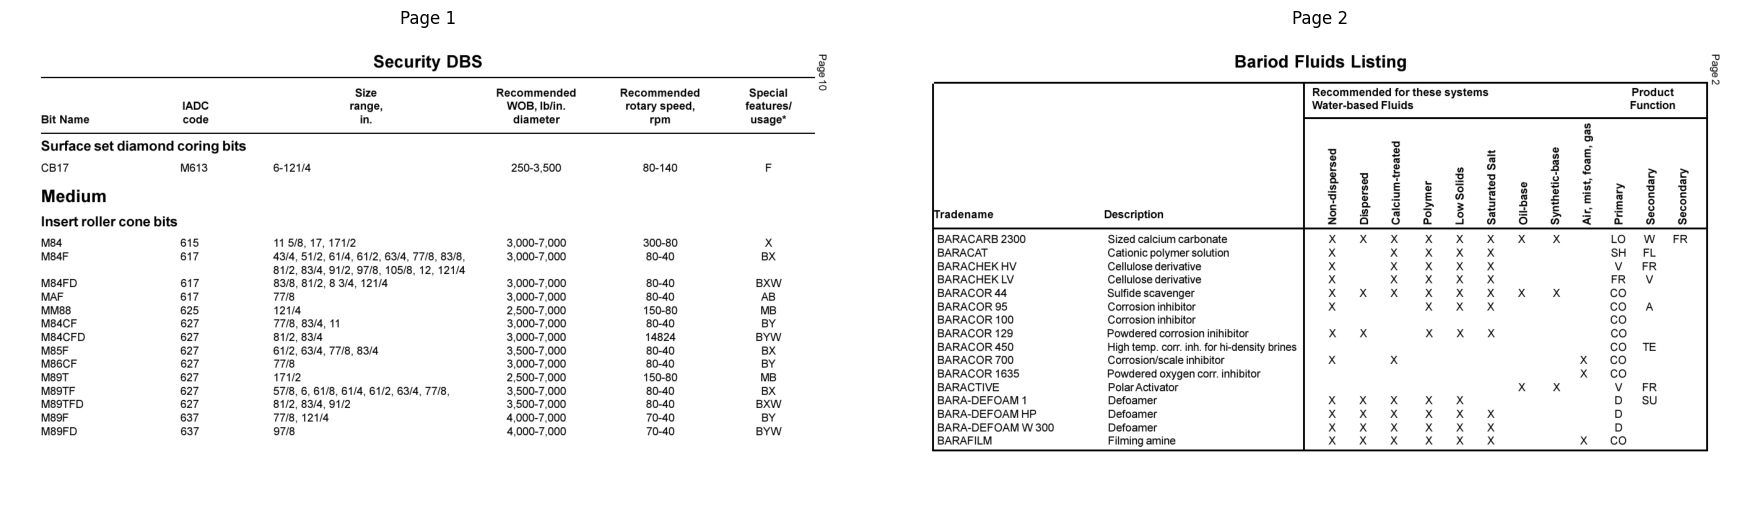

In [14]:
display_images_subplot()

In [187]:
image = Image.open("./output_images/page_1.png")
image = image.convert("RGB")

### Preprocessing

* Convert PDF into granular, semantically-rich units (nodes)

In [188]:
LAYOUTLMV2_MODEL = "microsoft/layoutlmv2-base-uncased"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [189]:

processor = LayoutLMv2Processor.from_pretrained(LAYOUTLMV2_MODEL, apply_ocr=False)
model = LayoutLMv2ForTokenClassification.from_pretrained(LAYOUTLMV2_MODEL).to(DEVICE)

Some weights of LayoutLMv2ForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlmv2-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [190]:
# Convert the pdf to images
def pdf_to_images(pdf_path):
    pages = convert_from_path(pdf_path)
    return pages


In [191]:
# OCR each page using Tesseract

def ocr_with_boxes(image):
    """Returns list of (text, bounding_box) from image."""
    data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)
    words = []
    for i in range(len(data['text'])):
        if int(data['conf'][i]) > 0 and data['text'][i].strip() != "":
            text = data['text'][i]
            bbox = (data['left'][i], data['top'][i], 
                    data['left'][i] + data['width'][i], 
                    data['top'][i] + data['height'][i])
            words.append((text, bbox))
    return words

In [192]:
# Inputs for LayoutLM2

def prepare_inputs(words, image):
    width, height = image.size

    # Normalizing the bounding boxes
    normalized_boxes = []
    for word, box in words:
        x0, y0, x1, y1 = box
        x0 = int((x0 / width) * 1000)
        y0 = int((y0 / height) * 1000)
        x1 = int((x1 / width) * 1000)
        y1 = int((y1 / height) * 1000)
        normalized_boxes.append([x0, y0, x1, y1])

    # Preparing the processor input
    encoding = processor(
        image,
        text=[w[0] for w in words],
        boxes=normalized_boxes,
        return_tensors="pt",
        truncation=True,
        padding="max_length"
    )
    return encoding


In [193]:
## Spatial Graph

def build_spatial_graph(words):
    G = nx.Graph()
    
    # nodes with attributes
    for idx, (text, bbox) in enumerate(words):
        G.add_node(idx, 
                   text=text, 
                   bbox=bbox,
                   center=((bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2))
        
    # edges based on spatial proximity
    for i in G.nodes:
        for j in G.nodes:
            if i >= j:
                continue
            # Compute Euclidean distance between centers
            xi, yi = G.nodes[i]['center']
            xj, yj = G.nodes[j]['center']
            distance = np.sqrt((xi - xj)**2 + (yi - yj)**2)
            
            if distance < 100:  
                G.add_edge(i, j, weight=distance)
    
    return G


In [194]:
## Preprocessing full

def preprocess_pdf(pdf_path):
    pages = pdf_to_images(pdf_path)
    
    all_graphs = []
    
    for page_num, image in enumerate(pages):
        print(f"Processing page {page_num + 1}...")
        
        # OCR
        words = ocr_with_boxes(image)
        
        if not words:
            print("No words detected on this page.")
            continue
        
        # LayoutLMv2 Inputs
        encoding = prepare_inputs(words, image)
        encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
        
        with torch.no_grad():
            outputs = model(**encoding)
        
        # Build Spatial Graph
        G = build_spatial_graph(words)
        
        all_graphs.append((page_num, G))
    
    return all_graphs

In [195]:
graphs = preprocess_pdf(test_sample_2)


Processing page 1...


In [196]:
graphs

[(0, <networkx.classes.graph.Graph at 0x7564263216d0>)]

In [197]:
import networkx as nx

def visualize_graph_3d_interactive_plotly(graph):
    """
    Visualizes a NetworkX graph in 3D interactively using Plotly.

    Args:
        graph (nx.Graph): The NetworkX graph to visualize.
    """
    if not graph.nodes:
        print("The graph is empty and cannot be visualized.")
        return

    labels = {node: data['text'] for node, data in graph.nodes(data=True)}
    pos_2d = nx.spring_layout(graph, seed=42)
    pos_3d = {node: (x, y, 0) for node, (x, y) in pos_2d.items()}  # Initial z=0

    edge_x = []
    edge_y = []
    edge_z = []
    for u, v, data in graph.edges(data=True):
        x0, y0, z0 = pos_3d[u]
        x1, y1, z1 = pos_3d[v]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
        edge_z.extend([z0, z1, None])

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        line=dict(width=0.5, color='#888'),
        hoverinfo='none',
        mode='lines'
    )

    node_x = []
    node_y = []
    node_z = []
    node_text = []
    for node, (x, y, z) in pos_3d.items():
        node_x.append(x)
        node_y.append(y)
        node_z.append(z)
        node_text.append(labels[node])

    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode='markers+text',
        marker=dict(size=20, color='lightblue'),
        text=node_text,
        textposition='middle center',
        hoverinfo='text'
    )

    fig = go.Figure(data=[edge_trace, node_trace])

    fig.update_layout(
        scene=dict(
            xaxis=dict(showbackground=False, zerolinecolor='lightgray', gridcolor='lightgray', showticklabels=False, title=''),
            yaxis=dict(showbackground=False, zerolinecolor='lightgray', gridcolor='lightgray', showticklabels=False, title=''),
            zaxis=dict(showbackground=False, zerolinecolor='lightgray', gridcolor='lightgray', showticklabels=False, title=''),
        ),
        showlegend=False,
        title='Interactive 3D Spatial Graph of PDF Page',
        margin=dict(r=20, b=10, l=10, t=40)
    )

    fig.show()


if graphs:
    page_num, graph_to_visualize = graphs[0]
    print(f"Visualizing the interactive 3D graph for page {page_num + 1}:")
    visualize_graph_3d_interactive_plotly(graph_to_visualize)
else:
    print("No graphs were generated.")

Visualizing the interactive 3D graph for page 1:


### Testing with LayoutLMv2 model

In [198]:

processor = LayoutLMv2Processor.from_pretrained("microsoft/layoutlmv2-base-uncased")

encoding = processor(image, return_offsets_mapping=True, return_tensors="pt")
offset_mapping = encoding.pop('offset_mapping')
print(encoding.keys())

model = LayoutLMv2ForTokenClassification.from_pretrained("nielsr/layoutlmv2-finetuned-funsd")
model.to(device)

outputs = model(**encoding)
print(outputs.logits.shape)

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'bbox', 'image'])
torch.Size([1, 480, 7])


In [199]:
def unnormalize_box(bbox, width, height):
     return [
         width * (bbox[0] / 1000),
         height * (bbox[1] / 1000),
         width * (bbox[2] / 1000),
         height * (bbox[3] / 1000),
     ]

predictions = outputs.logits.argmax(-1).squeeze().tolist()
token_boxes = encoding.bbox.squeeze().tolist()

width, height = image.size

In [200]:
dataset = load_dataset("nielsr/funsd", split="test")

labels = dataset.features['ner_tags'].feature.names
id2label = {v: k for v, k in enumerate(labels)}
label2color = {'question':'blue', 'answer':'green', 'header':'orange', 'other':'violet'}

is_subword = np.array(offset_mapping.squeeze().tolist())[:,0] != 0

true_predictions = [id2label[pred] for idx, pred in enumerate(predictions) if not is_subword[idx]]
true_boxes = [unnormalize_box(box, width, height) for idx, box in enumerate(token_boxes) if not is_subword[idx]]

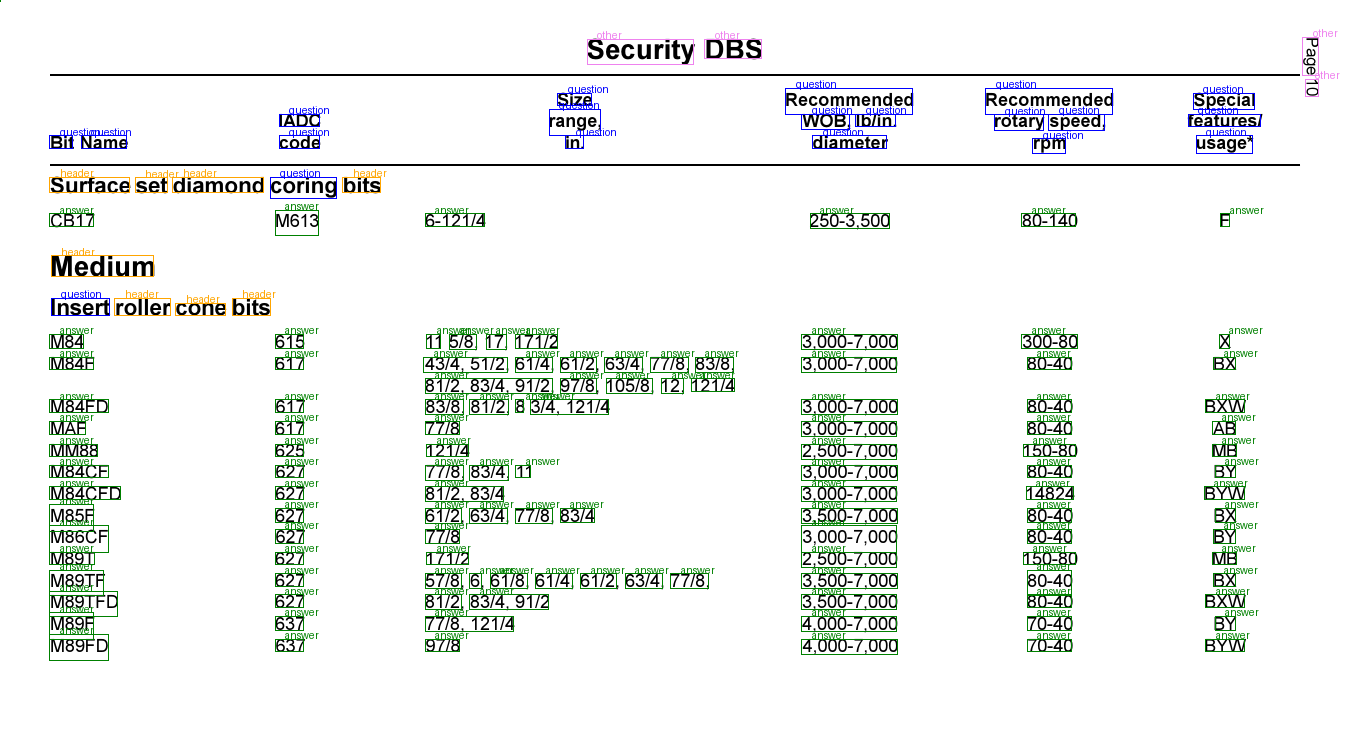

In [201]:
draw = ImageDraw.Draw(image)

font = ImageFont.load_default()

def iob_to_label(label):
    label = label[2:]
    if not label:
      return 'other'
    return label

label2color = {'question':'blue', 'answer':'green', 'header':'orange', 'other':'violet'}

for prediction, box in zip(true_predictions, true_boxes):
    predicted_label = iob_to_label(prediction).lower()
    draw.rectangle(box, outline=label2color[predicted_label])
    draw.text((box[0]+10, box[1]-10), text=predicted_label, fill=label2color[predicted_label], font=font)

image

### Table Region Chunking

* Group text blocks that are spatially close, which will help identify columns and rows

In [ ]:
def chunk_graph_into_regions(graphs, eps=50, min_samples=2):
    """
    Input: List of (page_idx, graph) tuples.
    Output: List of table region chunks (each chunk is a list of nodes).
    """
    all_chunks_per_page = []

    for page_idx, G in graphs:   # <-- unpack here
        nodes = list(G.nodes(data=True))

        if not nodes:
            all_chunks_per_page.append([])
            continue
        
        # node centers for clustering
        centers = []
        node_ids = []
        for node_id, data in nodes:
            bbox = data.get("bbox", [0, 0, 0, 0])
            x_center = (bbox[0] + bbox[2]) / 2
            y_center = (bbox[1] + bbox[3]) / 2
            centers.append([x_center, y_center])
            node_ids.append(node_id)

        centers = np.array(centers)

        clustering = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean').fit(centers)

        labels = clustering.labels_
        chunks = defaultdict(list)

        for idx, label in enumerate(labels):
            if label == -1:
                continue  # noise points are ignored
            chunks[label].append(node_ids[idx])

        page_chunks = []
        for label, node_list in chunks.items():
            subgraph = G.subgraph(node_list).copy()
            page_chunks.append(subgraph)

        all_chunks_per_page.append(page_chunks)

    return all_chunks_per_page


In [169]:

chunks = chunk_graph_into_regions(graphs)



In [170]:
chunks

[[<networkx.classes.graph.Graph at 0x75643fbac860>,

In [171]:
graphs

[(0, <networkx.classes.graph.Graph at 0x75643fc67ad0>)]

### Retrieval Stage (RAG)

* Find candidate groups (tables, headers, rows, cells) for deeper analysis

**Together AI** service

In [172]:
client_reference = together.Together(api_key=TOGETHER_API_KEY1)
async_client_reference = AsyncTogether(api_key=TOGETHER_API_KEY1)

client_aggregator = together.Together(api_key=TOGETHER_API_KEY2)
async_client_aggregator = AsyncTogether(api_key=TOGETHER_API_KEY2)

In [ ]:
# Reference LLMs (Mixtures)

reference_models = [
    "Qwen/Qwen2-72B-Instruct",
    "meta-llama/Llama-3.3-70B-Instruct-Turbo",
    "mistralai/Mixtral-8x22B-Instruct-v0.1",
]

# Aggregator Model
aggregator_model = "mistralai/Mixtral-8x22B-Instruct-v0.1"

# Prompt Template for each subgraph
PROMPT_TEMPLATE = """
You are a world-class document analyst.

You MUST return ONLY VALID JSON — no commentary, no explanations, no markdown (like ```json), nothing except the raw JSON object.

Format:
[
  {{
    "columns": [...],
    "rows": [{{...}}, {{...}}]
  }},
  ...
]

Instructions:
- The text represents the ENTIRE PAGE extracted sequentially.
- Multiple tables may exist: separate them cleanly into multiple JSON objects.
- Carefully infer table boundaries based on spatial and textual cues.
- Handle merged headers, misaligned rows, and partial rows.

Raw Page Text Blocks:
{table_blocks}

STRICT JSON OUTPUT ONLY.
"""

#  Aggregator system prompt
aggregator_system_prompt = """
You are the chief document analyst.
You have received multiple candidate answers for the same table extraction task.

Synthesize the FINAL, MOST ACCURATE version. No commentary. No markdown. ONLY strict JSON.

Carefully analyze the different candidate JSONs and synthesize a SINGLE final version that is:
Format:
[
  {{
    "columns": [...],
    "rows": [{{...}}, {{...}}]
  }},
  ...
]

If there are missing values, use null. If merging is needed, do it smartly.

STRICT JSON OUTPUT ONLY.
"""


In [180]:
# Function to run reference LLMs asynchronously
async def run_llm(model, user_prompt):
    """
    Asynchronously call a single reference LLM.
    """
    response = await async_client_reference.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=0.2,
        max_tokens=4096,   # Increased for full-page parsing
    )
    print(f"[Reference Model Completed]: {model}")
    return response.choices[0].message.content


# Function to extract tables from a chunk
async def extract_table_from_chunk(chunk_subgraph):
    """
    For one table region (chunk subgraph), perform Mixture-of-Agents RAG using aggregator model.
    """
    # prompt
    nodes = list(chunk_subgraph.nodes(data=True))
    nodes_sorted = sorted(nodes, key=lambda x: (x[1]["bbox"][1], x[1]["bbox"][0]))  # y_min, x_min
    table_blocks = "\n".join([data["text"] for node_id, data in nodes_sorted if data.get("text")])

    user_prompt = PROMPT_TEMPLATE.format(table_blocks=table_blocks.strip())

    # parallel call reference models
    results = await asyncio.gather(*[run_llm(model, user_prompt) for model in reference_models])

    # aggregate using aggregator model
    final_output = ""

    response = await async_client_aggregator.chat.completions.create(
        model=aggregator_model,
        messages=[
            {"role": "system", "content": aggregator_system_prompt},
            {"role": "user", "content": "\n\n".join(results)},
        ],
        temperature=0.2,
        stream=True,
    )

    async for chunk in response:
        if chunk.choices and chunk.choices[0].delta.content:
            delta = chunk.choices[0].delta.content
            final_output += delta

    return final_output

# Function to extract tables from all chunks
async def extract_all_tables(all_chunks):
    """
    Extract structured tables for all chunks asynchronously.
    """
    final_tables = []

    for page_idx, page_chunks in all_chunks:
        page_results = []

        for chunk_idx, chunk in enumerate(page_chunks):
            print(f"Extracting Page {page_idx} Chunk {chunk_idx}...")
            final_json = await extract_table_from_chunk(chunk)

            page_results.append({
                "page": page_idx,
                "chunk": chunk_idx,
                "table_json": final_json,
            })

        final_tables.append(page_results)

    return final_tables


In [181]:
graphs

[(0, <networkx.classes.graph.Graph at 0x75643fc67ad0>)]

In [177]:
_, graph = graphs[0]

In [178]:
graph

In [179]:
final_structured_tables = await extract_table_from_chunk(graph)


[Reference Model Completed]: mistralai/Mixtral-8x22B-Instruct-v0.1
[Reference Model Completed]: meta-llama/Llama-3.3-70B-Instruct-Turbo
[Reference Model Completed]: Qwen/Qwen2-72B-Instruct


In [182]:
final_structured_tables

' [\n  {\n    "columns": ["Product", "Water-based Fluids", "Function", "Secondary & Dispersed Solids", "Saturated mist, Polymer", "Oil-base @ 2%", "Low Air, Description"],\n    "rows": [\n      {\n        "Product": "BARACARB 2300",\n        "Water-based Fluids": "Sized calcium carbonate",\n        "Function": "X",\n        "Secondary & Dispersed Solids": "X",\n        "Saturated mist, Polymer": "X",\n        "Oil-base @ 2%": "x",\n        "Low Air, Description": "X"\n      },\n      {\n        "Product": "BARACAT",\n        "Water-based Fluids": "Cationic polymer solution",\n        "Function": "X",\n        "Secondary & Dispersed Solids": "%",\n        "Saturated mist, Polymer": "X",\n        "Oil-base @ 2%": "X",\n        "Low Air, Description": "X"\n      },\n      {\n        "Product": "BARACHEK HV",\n        "Water-based Fluids": "Cellulose derivative",\n        "Function": "X",\n        "Secondary & Dispersed Solids": "X",\n        "Saturated mist, Polymer": ">",\n        "Oil-b

In [141]:
with open("structured_tables_full.json", "w") as f:
    json.dump(json.loads(final_structured_tables), f, indent=4)

In [40]:
with open("final_structured_tables.json", "w") as f:
    json.dump(final_structured_tables, f, indent=4)

In [54]:
client = together.Together(api_key="41bad9b287c02b34b4a844bcfc21f18225cc0852f983652c8952908795a75c07")


In [58]:
def clean_table_json(table_json):
    """
    Clean and normalize the extracted JSON table structure.
    - Ensure columns are correctly parsed and rows are aligned.
    - Handle merged cells by ensuring rows have consistent column entries.
    """
    try:
        table = json.loads(table_json)
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return None

    # Check for empty or invalid table structure
    if not table.get("columns") or not table.get("rows"):
        print(f"Invalid table structure: Missing 'columns' or 'rows'.")
        return None

    columns = table["columns"]
    rows = table["rows"]

    # Normalize rows (e.g., fill missing cells with empty strings)
    normalized_rows = []
    for row in rows:
        normalized_row = {col: row.get(col, "") for col in columns}
        normalized_rows.append(normalized_row)

    # Ensure all rows have the same number of columns (use empty strings if needed)
    return {
        "columns": columns,
        "rows": normalized_rows
    }

def export_to_csv_or_excel(table_json, export_format="csv", output_file="extracted_table"):
    """
    Convert the table JSON into CSV or Excel format.
    """
    # Clean the table JSON
    cleaned_table = clean_table_json(table_json)
    if cleaned_table is None:
        print("Skipping export due to invalid table data.")
        return "Error: Invalid Table Data"

    columns = cleaned_table["columns"]
    rows = cleaned_table["rows"]

    # Convert to pandas DataFrame for easier export
    df = pd.DataFrame(rows, columns=columns)

    if export_format.lower() == "csv":
        output_path = f"{output_file}.csv"
        df.to_csv(output_path, index=False)
        print(f"Table exported to CSV: {output_path}")
    elif export_format.lower() == "excel":
        output_path = f"{output_file}.xlsx"
        df.to_excel(output_path, index=False)
        print(f"Table exported to Excel: {output_path}")
    else:
        print(f"Unsupported export format: {export_format}")
        return "Unsupported format"

    return output_path


In [59]:
# Example of calling the function for one chunk of table JSON
for page_result in final_structured_tables:
    for table in page_result:
        table_json = table["table_json"]
        # Export the cleaned table to CSV or Excel
        export_to_csv_or_excel(table_json, export_format="csv", output_file=f"table_page_{table['page']}_chunk_{table['chunk']}")


Invalid table structure: Missing 'columns' or 'rows'.
Skipping export due to invalid table data.
Invalid table structure: Missing 'columns' or 'rows'.
Skipping export due to invalid table data.
Invalid table structure: Missing 'columns' or 'rows'.
Skipping export due to invalid table data.
Table exported to CSV: table_page_0_chunk_3.csv
Error parsing JSON: Expecting value: line 1 column 2 (char 1)
Skipping export due to invalid table data.
Table exported to CSV: table_page_0_chunk_5.csv
Error parsing JSON: Expecting value: line 1 column 2 (char 1)
Skipping export due to invalid table data.
Table exported to CSV: table_page_0_chunk_7.csv
Error parsing JSON: Expecting value: line 1 column 2 (char 1)
Skipping export due to invalid table data.
Table exported to CSV: table_page_0_chunk_9.csv
Error parsing JSON: Expecting value: line 1 column 2 (char 1)
Skipping export due to invalid table data.
Table exported to CSV: table_page_0_chunk_11.csv


### Post-Processing Stage

In [183]:
parsed_data = json.loads(final_structured_tables)

In [184]:
rows = parsed_data[0]['rows']

In [185]:
df = pd.DataFrame(rows)


In [186]:
df

,Product,Water-based Fluids,Function,Secondary & Dispersed Solids,"Saturated mist, Polymer",Oil-base @ 2%,"Low Air, Description"
0,BARACARB 2300,Sized calcium carbonate,X,X,X,x,X
1,BARACAT,Cationic polymer solution,X,%,X,X,X
2,BARACHEK HV,Cellulose derivative,X,X,>,X,X
3,BARACHEK LV,Cellulose derivative,X,X,X,X,X
4,BARACOR 44,Sulfide scavenger,X,X,X,X,X
5,BARACOR 95,Corrosion inhibitor,X,X,X,>,X
6,BARACOR 100,Corrosion inhibitor,,,,,
7,BARACOR 129,Powdered corrosion inihibitor,x,B3,B3,B3,BARACOR 450
8,High temp. inh. for hi-density brines corr.,,,,,,
9,BARACOR 700,Corrosion/scale inhibitor,B3,,,,
